  # HW2: Policy Gradiant



  > - Full Name: **Yashar Zafari Haqqi**



  > - Student ID: **404210253**











  ## Objective







  In this notebook, you will implement the **REINFORCE policy gradient algorithm** (also known as Monte Carlo policy gradient) to train an agent on the **CartPole‑v1** environment from OpenAI Gym. REINFORCE is a fundamental policy‑based reinforcement learning method that directly optimises the policy parameters by performing stochastic gradient ascent on the expected cumulative reward. However, the standard REINFORCE update is known to suffer from **high variance**, which can lead to slow convergence and unstable learning curves.







  ## Variance Reduction Techniques







  To address this issue, this notebook further explores three variance‑reduction strategies that are commonly applied to the REINFORCE algorithm. You will implement each of them and empirically analyse their effects on learning speed, stability, and final performance. The techniques are:







  1. **The causality trick (reward‑to‑go)**



     Instead of using the full return from the start of an episode, this method replaces the cumulative reward with the sum of future rewards from each time step onward. By ignoring rewards obtained before the current action, the gradient estimator retains the same unbiasedness while significantly reducing variance.







  2. **Constant baseline**



     A fixed scalar baseline is subtracted from the return (or the reward‑to‑go) in the policy gradient estimate. Subtracting a constant does not introduce bias, but a well‑chosen constant (e.g., the average return over recent episodes) can reduce variance by centring the advantage estimates.







  3. **Learned baseline (value function baseline)**



     A more sophisticated approach that uses a separate function approximator (typically a neural network) to estimate the state‑value function. This learned baseline adapts during training and provides a state‑dependent offset. The advantage estimate then often yields the lowest variance among these three methods, at the cost of adding a second learning process.







  ## Implementation and Analysis







  You will implement the core REINFORCE update, then systematically extend it with each of the three variance‑reduction techniques. For every variant, you will run multiple training episodes, plot the smoothed episode returns, and compare convergence behaviour. The notebook will guide you through:







  - Setting up the CartPole‑v1 environment (discrete action space, continuous observation space).



  - Defining a policy network (e.g., a shallow multi‑layer perceptron) with a softmax output layer.



  - Writing the training loop that collects episodes, computes policy gradients, and updates the policy.



  - Modifying the advantage estimator to incorporate causality and baseline subtractions.



  - Training and evaluating each variant with identical random seeds for fair comparison.







  By the end of this notebook, you will gain hands‑on insight into how different variance‑reduction mechanisms affect the practical performance of Monte Carlo policy gradient methods.

  # Setup

  All required packages are pre-installed if using Google Colab.





  Import the following libraries.

In [1]:
# Imports
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gym
import matplotlib
import matplotlib.pyplot as plt
import base64
import imageio
import IPython
import logging
import warnings

# Disable warnings
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE



device(type='cpu')

  Note: While we check for CUDA availability, using a GPU is not strictly necessary for this assignment. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.

  Set a fix seed to be able to compare results

In [2]:
def set_seed(seed=333):
    # Set seeds for reproducibility
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(333)



  Configure Matplotlib for Interactive and XKCD-Style Plots

In [3]:
# Set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
plt.xkcd(scale=1, length=100, randomness=2)
matplotlib.rcParams['figure.figsize'] = (12, 6)



  Record and Embed Simulation Videos in Jupyter Notebook

  <b>embed_mp4:</b> Converts an MP4 video into a base64-encoded HTML tag for display in Jupyter Notebook.



  <br>



  <b>record_simulation:</b> Runs a policy in the environment, records the simulation, and saves it as an MP4 video.

In [4]:
def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)

def record_simulation(env, policy_net, filename, episodes=1, fps=30):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(episodes):
            state, info = env.reset()
            frame = env.render()  # Capture the first frame (numpy array)
            video.append_data(frame)

            done = False
            while not done:
                state_tensor = torch.FloatTensor(state).to(DEVICE)
                with torch.no_grad():
                    action_probs = policy_net(state_tensor)
                action = torch.argmax(action_probs).item()
                state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                frame = env.render()  # Capture the frame after taking the action
                video.append_data(frame)
    return embed_mp4(filename)



  # Explore the environment

  Initialize CartPole Environment and Display State & Action Spaces

In [5]:
# Create the CartPole environment
env = gym.make("CartPole-v1")

# Print observation and action space
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)



Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


  **Question**







  How are the observation and action spaces defined in the CartPole environment?







  **Answer:**





  Define a Random Policy for Action Selection

In [6]:
class RandomPolicy(object):

    def __init__(self, action_space_n):
        self.action_space_n = action_space_n

    def __call__(self, state):
        action_values = torch.rand(self.action_space_n)
        return action_values



  Visualize the random policy.

In [7]:
import numpy as np

random_policy = RandomPolicy(env.action_space.n)

record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), random_policy, "Video_CartPole_random_policy")



  # Agent with REINFORCE: Normal vs Causality vs Simple Baseline vs Learned Baseline





  ### Policy Network Definition

  To define a neural network that represents the agent’s policy for selecting actions.







  The policy network takes the environment’s state as input and outputs a probability distribution over possible actions.

In [8]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, state):
        return self.fc(state)


  ### REINFORCE without Causality







  #### 1. The Objective Function



  In Policy Gradient methods, we aim to maximize the expected return:



  $$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [G(\tau)]$$



  where $\tau = (s_0, a_0, s_1, a_1, \dots, s_T)$ is a trajectory sampled from the policy $\pi_\theta$, and $G(\tau)$ is the total discounted return.







  #### 2. The Policy Gradient Theorem



  The gradient of the objective function is given by:



  $$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \left( \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \right) G(\tau) \right]$$







  #### 3. Full Return vs. Reward-to-go



  In the code implementation `reinforce_no_causality`, we use the **Full Return** $G_0$ for every action in the trajectory:



  - **Definition of $G_0$**: $G_0 = \sum_{k=0}^{T} \gamma^k R_k$



  - **Update Rule**: $\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) G_0$







  #### Definitions:



  - **$\pi_\theta(a_t | s_t)$**: The probability of taking action $a_t$ given state $s_t$ under parameters $\theta$.



  - **$\nabla_\theta \log \pi_\theta(a_t | s_t)$**: The 'score function' or direction in parameter space that increases the probability of action $a_t$.



  - **$G_0$**: The total scalar reward of the entire episode. If the episode was good, $G_0$ is high, and we push the probabilities of *all* actions taken in that episode 'up' equally.





In [9]:
def reinforce_no_causality(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=333)
        log_probs = []
        rewards = []
        done = False

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            logits = policy_net(state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        # Full return G0
        G0 = 0.0
        for r in reversed(rewards):
            G0 = r + gamma * G0

        log_probs = torch.stack(log_probs)
        loss = -(log_probs * G0).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}")

    return rewards_per_episode



  **Question:**







  Why does this method has high variance?















  **Answer:**

  ### REINFORCE with Causality

  To implement a function that calculates the discounted return for each timestep in an episode.







  $$[



  G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}



  ]$$

In [10]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return returns



  To train the agent using the standard policy gradient method.



  The REINFORCE algorithm updates policy parameters by using the log-probability of actions multiplied by the discounted return.







  This algorithm optimizes a **stochastic policy** $( \pi_{\theta}(a_t \mid s_t) )$ by updating its parameters in the direction that increases expected rewards. The update rule is based on the **policy gradient theorem**:







  $$[



  \theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) G_t



  ]$$







  where:







  - $( \theta )$ are the policy parameters (weights of the neural network).



  - $( \alpha )$ is the learning rate.



  - $( G_t )$ is the **discounted return** from timestep $( t )$:







  - $( \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) )$ is the gradient of the log-probability of the selected action, used to adjust the policy in the correct direction.

In [11]:
def reinforce(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=333)
        log_probs = []
        rewards = []
        done = False

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            logits = policy_net(state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.tensor(returns, dtype=torch.float32, device=DEVICE)

        # Normalize returns for stability
        returns_tensor = (returns_tensor - returns_tensor.mean()) / (returns_tensor.std() + 1e-8)

        log_probs = torch.stack(log_probs)
        loss = -(log_probs * returns_tensor).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}")

    return rewards_per_episode


  ### REINFORCE with a Constant Baseline







  A simple way to reduce variance is to subtract a constant baseline from the returns. A common choice for this constant is the average return of the episode:







  $$\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t | s_t) (G_t - b)$$







  where $b = \frac{1}{T} \sum_{t=0}^T G_t$.

In [12]:
def reinforce_constant_baseline(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=333)
        log_probs = []
        rewards = []
        done = False

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            logits = policy_net(state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.tensor(returns, dtype=torch.float32, device=DEVICE)
        baseline = returns_tensor.mean()
        advantages = returns_tensor - baseline

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs = torch.stack(log_probs)
        loss = -(log_probs * advantages).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}")

    return rewards_per_episode


  ### Value Network Definition (Baseline Network)

  Defines a neural network that approximates the value function, which estimates the expected return from a given state. The network takes the environment’s state as input and outputs a scalar value, representing the long-term reward the agent can expect from that state.

In [13]:
# TODO: Define the Value Network (Baseline)
class ValueNetwork(nn.Module):
    def __init__(self, input_dim):
        super(ValueNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state):
        return self.fc(state)



  ### Implementing REINFORCE with a Learned Baseline

  To reduce variance in policy updates, we introduce a **baseline** function $( V(s) )$, which estimates the expected return from a given state. Instead of using the full return $( G_t )$, we adjust the policy update by incorporating the baseline:







  $$[



  \theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) (G_t - V(s_t))



  ]$$







  where:







  - $( \theta )$ are the policy parameters (weights of the neural network).



  - $( \alpha )$ is the learning rate.



  - $( G_t )$ is the **discounted return** from timestep $( t )$:







    $$[



    G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}



    ]$$







  - $( V(s_t) )$ is the **baseline function**, estimated by a **value network**, which is trained using mean squared error (MSE) between predicted values and actual returns:







    $$[



    L = \frac{1}{N} \sum_{t=0}^{N} (G_t - V(s_t))^2



    ]$$







  The introduction of the baseline does not change the expected value of the gradient but significantly **reduces variance**, leading to more stable learning.





In [14]:
def reinforce_with_baseline(env, policy_net, baseline_net, policy_optimizer, baseline_optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=333)
        log_probs = []
        rewards = []
        states = []
        done = False

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            logits = policy_net(state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            states.append(state_tensor)
            state = next_state

        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.tensor(returns, dtype=torch.float32, device=DEVICE)

        # Baseline predictions
        states_batch = torch.stack(states)
        values = baseline_net(states_batch).squeeze(-1)

        # Detach advantages once (no gradient through baseline)
        advantages = (returns_tensor - values).detach()
        # Normalize for stability
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs = torch.stack(log_probs)
        policy_loss = -(log_probs * advantages).sum()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        # Baseline training (MSE to returns)
        baseline_loss = nn.MSELoss()(values, returns_tensor.detach())
        baseline_optimizer.zero_grad()
        baseline_loss.backward()
        baseline_optimizer.step()

        total_reward = sum(rewards)
        rewards_per_episode.append(total_reward)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}")

    return rewards_per_episode


  ### Training

  To define key hyperparameters that influence training efficiency and convergence.







  Hyperparameters like learning rate, discount factor, and number of episodes significantly impact the training process. Proper tuning is necessary to ensure stable learning while avoiding slow convergence or premature convergence to suboptimal policies.

In [15]:
# TODO: Define all necessary hyperparameters
INPUT_DIM = env.observation_space.shape[0]   # 4
OUTPUT_DIM = env.action_space.n               # 2
LEARNING_RATE = 0.001
DISCOUNT_FACTOR = 0.99
NUM_EPISODES = 2000



In [16]:
# 1. Training REINFORCE without Causality (Full Return)
print("--- Training REINFORCE: No Causality (Full Return) ---")
# Use a fresh policy network
policy_net_no_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_no_causality = optim.Adam(policy_net_no_causality.parameters(), lr=LEARNING_RATE)

rewards_no_causality = reinforce_no_causality(
    env, policy_net_no_causality, optimizer_no_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)



--- Training REINFORCE: No Causality (Full Return) ---
Episode 100/2000, Total Reward: 65.0
Episode 200/2000, Total Reward: 51.0
Episode 300/2000, Total Reward: 43.0
Episode 400/2000, Total Reward: 26.0
Episode 500/2000, Total Reward: 81.0
Episode 600/2000, Total Reward: 75.0
Episode 700/2000, Total Reward: 169.0
Episode 800/2000, Total Reward: 302.0
Episode 900/2000, Total Reward: 147.0
Episode 1000/2000, Total Reward: 80.0
Episode 1100/2000, Total Reward: 126.0
Episode 1200/2000, Total Reward: 192.0
Episode 1300/2000, Total Reward: 126.0
Episode 1400/2000, Total Reward: 196.0
Episode 1500/2000, Total Reward: 242.0
Episode 1600/2000, Total Reward: 162.0
Episode 1700/2000, Total Reward: 107.0
Episode 1800/2000, Total Reward: 72.0
Episode 1900/2000, Total Reward: 103.0
Episode 2000/2000, Total Reward: 72.0


In [17]:
# 2. Training REINFORCE with Causality (No Baseline)
print("--- Training REINFORCE: With Causality (No Baseline) ---")
policy_net_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_causality = optim.Adam(policy_net_causality.parameters(), lr=LEARNING_RATE)

rewards_no_baseline = reinforce(
    env, policy_net_causality, optimizer_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)



--- Training REINFORCE: With Causality (No Baseline) ---
Episode 100/2000, Total Reward: 23.0
Episode 200/2000, Total Reward: 151.0
Episode 300/2000, Total Reward: 102.0
Episode 400/2000, Total Reward: 308.0
Episode 500/2000, Total Reward: 211.0
Episode 600/2000, Total Reward: 500.0
Episode 700/2000, Total Reward: 500.0
Episode 800/2000, Total Reward: 500.0
Episode 900/2000, Total Reward: 500.0
Episode 1000/2000, Total Reward: 500.0
Episode 1100/2000, Total Reward: 500.0
Episode 1200/2000, Total Reward: 500.0
Episode 1300/2000, Total Reward: 500.0
Episode 1400/2000, Total Reward: 397.0
Episode 1500/2000, Total Reward: 172.0
Episode 1600/2000, Total Reward: 500.0
Episode 1700/2000, Total Reward: 500.0
Episode 1800/2000, Total Reward: 500.0
Episode 1900/2000, Total Reward: 500.0
Episode 2000/2000, Total Reward: 500.0


In [18]:
# 3. Training REINFORCE with Constant Baseline
print("--- Training REINFORCE: Constant Baseline ---")
policy_net_const_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_const_baseline = optim.Adam(policy_net_const_baseline.parameters(), lr=LEARNING_RATE)

rewards_constant_baseline = reinforce_constant_baseline(
    env, policy_net_const_baseline, optimizer_const_baseline,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)



--- Training REINFORCE: Constant Baseline ---
Episode 100/2000, Total Reward: 42.0
Episode 200/2000, Total Reward: 76.0
Episode 300/2000, Total Reward: 64.0
Episode 400/2000, Total Reward: 219.0
Episode 500/2000, Total Reward: 500.0
Episode 600/2000, Total Reward: 166.0
Episode 700/2000, Total Reward: 375.0
Episode 800/2000, Total Reward: 500.0
Episode 900/2000, Total Reward: 500.0
Episode 1000/2000, Total Reward: 500.0
Episode 1100/2000, Total Reward: 500.0
Episode 1200/2000, Total Reward: 500.0
Episode 1300/2000, Total Reward: 500.0
Episode 1400/2000, Total Reward: 500.0
Episode 1500/2000, Total Reward: 500.0
Episode 1600/2000, Total Reward: 500.0
Episode 1700/2000, Total Reward: 500.0
Episode 1800/2000, Total Reward: 500.0
Episode 1900/2000, Total Reward: 500.0
Episode 2000/2000, Total Reward: 500.0


In [19]:
# 4. Training REINFORCE with Learned Baseline
print("--- Training REINFORCE: Learned Baseline ---")
policy_net_learned_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
value_net_baseline = ValueNetwork(INPUT_DIM).to(DEVICE)

policy_opt_learned = optim.Adam(policy_net_learned_baseline.parameters(), lr=LEARNING_RATE)
value_opt_learned = optim.Adam(value_net_baseline.parameters(), lr=LEARNING_RATE)

rewards_with_baseline = reinforce_with_baseline(
    env, policy_net_learned_baseline, value_net_baseline,
    policy_opt_learned, value_opt_learned,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)



--- Training REINFORCE: Learned Baseline ---
Episode 100/2000, Total Reward: 29.0
Episode 200/2000, Total Reward: 27.0
Episode 300/2000, Total Reward: 235.0
Episode 400/2000, Total Reward: 376.0
Episode 500/2000, Total Reward: 134.0
Episode 600/2000, Total Reward: 214.0
Episode 700/2000, Total Reward: 472.0
Episode 800/2000, Total Reward: 500.0
Episode 900/2000, Total Reward: 500.0
Episode 1000/2000, Total Reward: 500.0
Episode 1100/2000, Total Reward: 500.0
Episode 1200/2000, Total Reward: 428.0
Episode 1300/2000, Total Reward: 500.0
Episode 1400/2000, Total Reward: 500.0
Episode 1500/2000, Total Reward: 500.0
Episode 1600/2000, Total Reward: 500.0
Episode 1700/2000, Total Reward: 500.0
Episode 1800/2000, Total Reward: 500.0
Episode 1900/2000, Total Reward: 500.0
Episode 2000/2000, Total Reward: 500.0


## Save Trained Models

In [20]:
import os

os.makedirs("models", exist_ok=True)

# Save policy networks
torch.save(policy_net_no_causality.state_dict(), "models/policy_no_causality.pth")
torch.save(policy_net_causality.state_dict(), "models/policy_no_baseline.pth")
torch.save(policy_net_const_baseline.state_dict(), "models/policy_constant_baseline.pth")
torch.save(policy_net_learned_baseline.state_dict(), "models/policy_learned_baseline.pth")

# Save the learned value network (baseline)
torch.save(value_net_baseline.state_dict(), "models/value_learned_baseline.pth")

print("All models saved to the 'models/' directory.")

All models saved to the 'models/' directory.


  # Plot and Comparing Results





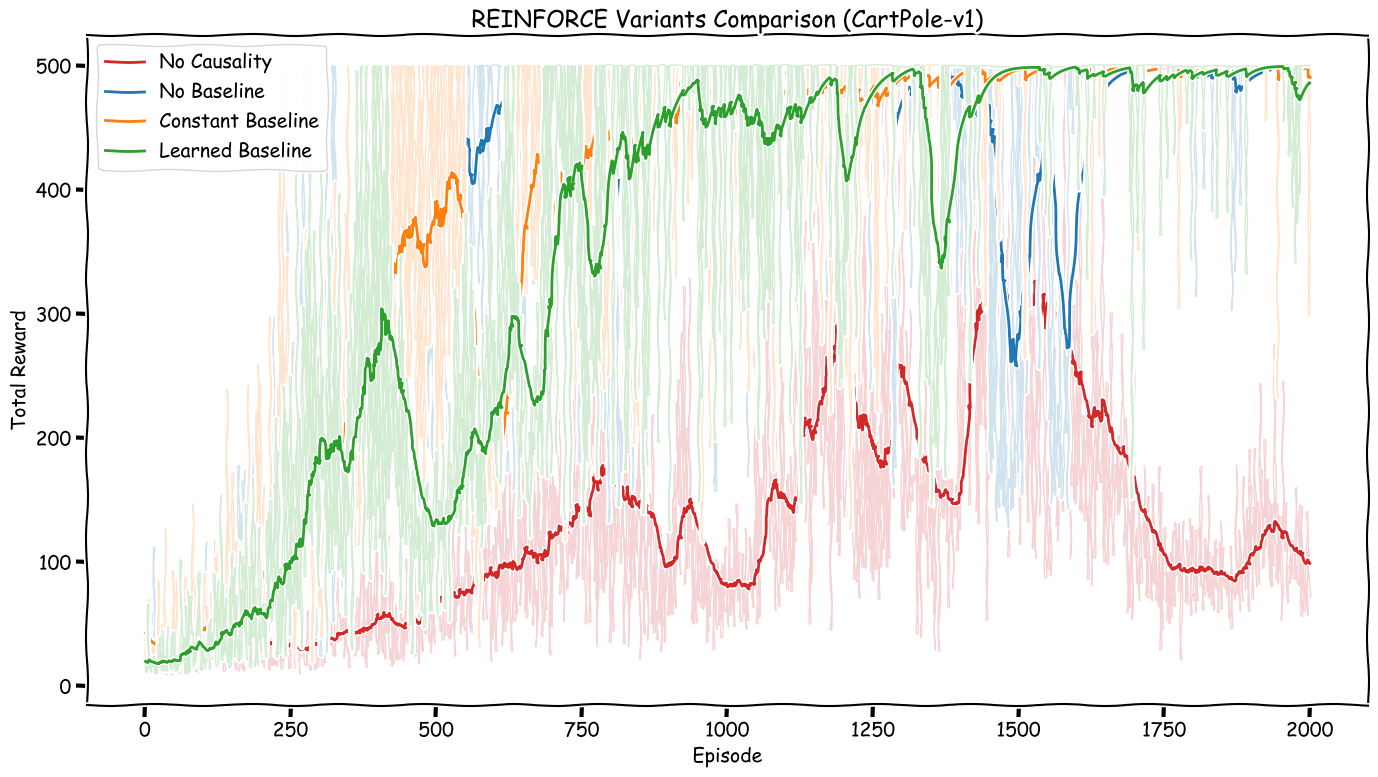

In [ ]:
# TODO: Plotting Results
window_size = 50

def exponential_moving_average(data, window_size):
    """Compute exponential moving average with specified smoothing factor."""
    if len(data) == 0:
        return data
    alpha = 2.0 / (window_size + 1)  # smoothing factor
    ema = [data[0]]
    for value in data[1:]:
        ema.append(alpha * value + (1 - alpha) * ema[-1])
    return ema

# Populate the methods list with actual results
methods = [
    (rewards_no_causality, "No Causality", "tab:red"),
    (rewards_no_baseline, "No Baseline", "tab:blue"),
    (rewards_constant_baseline, "Constant Baseline", "tab:orange"),
    (rewards_with_baseline, "Learned Baseline", "tab:green")
]

plt.figure(figsize=(14, 8))

# Plot raw data (semi-transparent) and EMA (solid line) for each method
for rewards, label, color in methods:
    episodes = np.arange(1, len(rewards) + 1)
    # Raw data
    plt.plot(episodes, rewards, alpha=0.2, color=color, linewidth=1)
    # EMA smoothed
    if len(rewards) > 0:
        ema = exponential_moving_average(rewards, window_size)
        plt.plot(episodes, ema, label=label, color=color, linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("REINFORCE Variants Comparison (CartPole-v1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [22]:
# Calculate and print statistics for all 4 methods
results_stats = [
    ("No Causality", rewards_no_causality),
    ("No Baseline", rewards_no_baseline),
    ("Constant Baseline", rewards_constant_baseline),
    ("Learned Baseline", rewards_with_baseline)
]

for name, rewards in results_stats:
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    print(f"{name}: mean_reward = {mean_reward:.1f} +/- {std_reward:.1f}")



No Causality: mean_reward = 130.8 +/- 107.4
No Baseline: mean_reward = 390.7 +/- 165.4
Constant Baseline: mean_reward = 389.8 +/- 163.4
Learned Baseline: mean_reward = 360.4 +/- 175.9


  **Question:**







  Based on the results, how does REINFORCE with a baseline compare to REINFORCE without a baseline in terms of performance?







  **Answer:**





  **Question:**







  Based on the results, how does REINFORCE with a constant baseline compare to REINFORCE with a learned baseline in terms of performance?







  **Answer:**





  **Question:**







  Based on the results, how does REINFORCE without causality trick compare to REINFORCE with causality trick in terms of performance?











  **Answer:**





  **Question:**







  Explain how variance affects policy gradient methods, particularly in the context of estimating gradients from sampled trajectories.







  **Answer:**

  # Simulation

In [23]:
# Record the simulation using the optimal policy no baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_causality, "Video_CartPole_no_baseline")



In [24]:
# Record the simulation using the policy trained without causality trick
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_no_causality, "Video_CartPole_no_causality")



In [25]:
# Record the simulation using the policy trained with constant baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_const_baseline, "Video_CartPole_constant_baseline")



In [26]:
# Record the simulation using the optimal policy with baseline
record_simulation(gym.make("CartPole-v1", render_mode='rgb_array'), policy_net_learned_baseline, "Video_CartPole_with_baseline")



  **Question:**







  According to the simulations, how does each algorithm perform on the task after the training?







  **Answer:**